In [34]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("heart_disease_data.csv")  # update filename
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [35]:
# # Check duplicate columns
df.columns[df.columns.duplicated()]

# Rename properly if needed
df.rename(columns={
    'HeartDiseaseorAttack': 'HeartDisease'
}, inplace=True)
df.head()

,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [36]:
categorical_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDisease', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [37]:
df.isnull().sum()

HeartDisease         0
HighBP               0
HighChol             0
CholCheck            0
BMI                  0
Smoker               0
Stroke               0
Diabetes             0
PhysActivity         0
Fruits               0
Veggies              0
HvyAlcoholConsump    0
AnyHealthcare        0
NoDocbcCost          0
GenHlth              0
MentHlth             0
PhysHlth             0
DiffWalk             0
Sex                  0
Age                  0
Education            0
Income               0
dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   HeartDisease       253680 non-null  category
 1   HighBP             253680 non-null  category
 2   HighChol           253680 non-null  category
 3   CholCheck          253680 non-null  category
 4   BMI                253680 non-null  int64   
 5   Smoker             253680 non-null  category
 6   Stroke             253680 non-null  category
 7   Diabetes           253680 non-null  int64   
 8   PhysActivity       253680 non-null  category
 9   Fruits             253680 non-null  category
 10  Veggies            253680 non-null  category
 11  HvyAlcoholConsump  253680 non-null  category
 12  AnyHealthcare      253680 non-null  category
 13  NoDocbcCost        253680 non-null  category
 14  GenHlth            253680 non-null  int64   
 15  MentHlth           253680 non-null

In [39]:
df['HeartDisease'].value_counts(normalize=True)

HeartDisease
0    0.905814
1    0.094186
Name: proportion, dtype: float64

In [40]:
df.groupby('HeartDisease', observed=True).mean(numeric_only=True)

,BMI,Diabetes,GenHlth,MentHlth,PhysHlth,Age,Education,Income
HeartDisease,,,,,,,,
0,28.269624,0.256337,2.422369,3.030306,3.731299,7.813858,5.082093,6.148050
1,29.466622,0.687231,3.367555,4.670322,9.154439,10.131210,4.745951,5.148161


In [41]:
cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'PhysActivity', 'DiffWalk']

for col in cols:
    print("\n", col)
    print(pd.crosstab(df[col], df['HeartDisease'], normalize='index'))


 HighBP
HeartDisease         0         1
HighBP                          
0             0.958820  0.041180
1             0.835264  0.164736

 HighChol
HeartDisease         0         1
HighChol                        
0             0.951126  0.048874
1             0.844290  0.155710

 Smoker
HeartDisease         0         1
Smoker                          
0             0.935635  0.064365
1             0.868345  0.131655

 Stroke
HeartDisease         0         1
Stroke                          
0             0.918007  0.081993
1             0.617470  0.382530

 PhysActivity
HeartDisease         0         1
PhysActivity                    
0             0.860865  0.139135
1             0.920279  0.079721

 DiffWalk
HeartDisease         0         1
DiffWalk                        
0             0.933755  0.066245
1             0.767663  0.232337


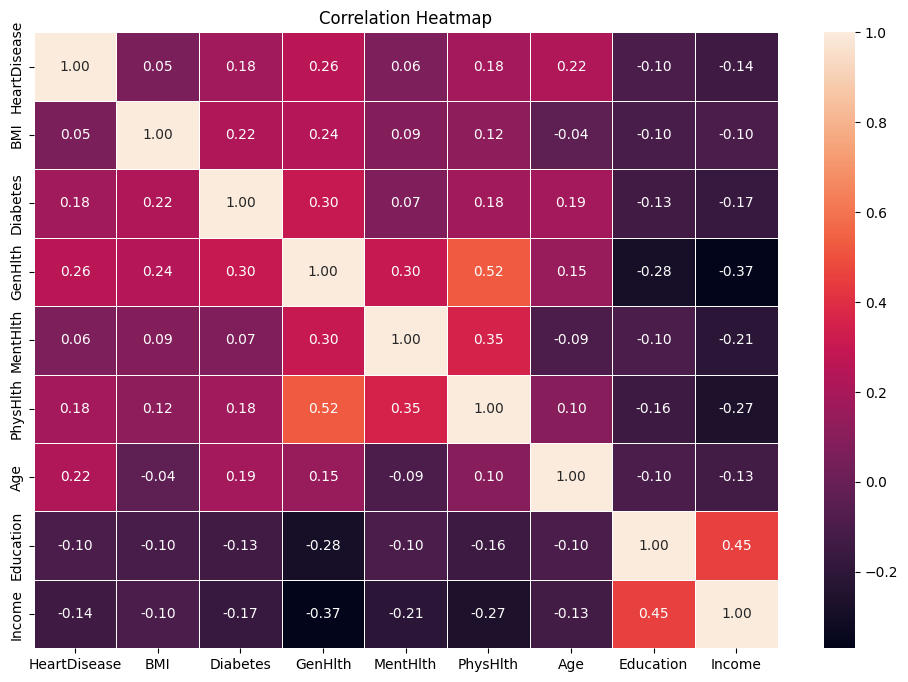

HeartDisease    1.000000
GenHlth         0.258383
Age             0.221618
PhysHlth        0.181698
Diabetes        0.180272
MentHlth        0.064621
BMI             0.052904
Education      -0.099600
Income         -0.141011
Name: HeartDisease, dtype: float64


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ensure numeric
df['HeartDisease'] = pd.to_numeric(df['HeartDisease'], errors='coerce')

# correlation
corr = df.corr(numeric_only=True)

# heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# target correlation
print(corr['HeartDisease'].sort_values(ascending=False))

In [43]:
df['HeartDisease'] = df['HeartDisease'].astype(int)

corr = df.corr(numeric_only=True)

print(corr['HeartDisease'].sort_values(ascending=False))

HeartDisease    1.000000
GenHlth         0.258383
Age             0.221618
PhysHlth        0.181698
Diabetes        0.180272
MentHlth        0.064621
BMI             0.052904
Education      -0.099600
Income         -0.141011
Name: HeartDisease, dtype: float64
